# Covid-19 Risk Classification

## Objectives
* To build **Random Forest Classifier** and **Gradient Boosted Classifier** models that will predict whether an individual is likely to contract covid-19 based on the given dataset.
* To evaluate models performance.
* To perform comparative insights into the algorithms performance.
* To analyze feature importance and discuss practical implications of the models.

In [2]:
# Import Pandas
import pandas as pd

# Import matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Data
covid_data = pd.read_csv(r"C:\Users\Alex\Downloads\coronavirusdataset.csv")

#View the top of the dataset
covid_data.head()


,batch_date,test_name,swab_type,covid19_test_results,age,high_risk_exposure_occupation,high_risk_interactions,diabetes,chd,htn,...,headache,loss_of_smell,loss_of_taste,runny_nose,muscle_sore,sore_throat,cxr_findings,cxr_impression,cxr_label,cxr_link
0,2020-10-20,"SARS-CoV-2, NAA",Nasal,Negative,39,False,NaN,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
1,2020-10-20,COVID-19 PCR External Result,Nasal,Negative,56,False,NaN,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
2,2020-10-20,Rapid COVID-19 PCR Test,Nasal,Negative,35,False,NaN,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
3,2020-10-20,Rapid COVID-19 PCR Test,Nasal,Negative,37,False,NaN,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN
4,2020-10-20,Rapid COVID-19 PCR Test,Nasal,Negative,42,False,NaN,False,False,False,...,False,False,False,False,False,False,NaN,NaN,NaN,NaN


### Comments
* The dataset was loaded successfully.
* The first 5 rows and 45 columns were displayed successfully.
* They provide an overview of how the data is structured.
* Each record represents an individual COVID-19 test case, including personal attributes (e.g., age), test information (e.g., swab type, test name), comorbidities, symptoms, and diagnostic results.
* Viewing the preview helps verify that the data was imported correctly and allow assessment of the types of variables to analyze in subsequent steps.


In [3]:
# Check the number of columns
covid_data.columns

Index(['batch_date', 'test_name', 'swab_type', 'covid19_test_results', 'age',
       'high_risk_exposure_occupation', 'high_risk_interactions', 'diabetes',
       'chd', 'htn', 'cancer', 'asthma', 'copd', 'autoimmune_dis', 'smoker',
       'temperature', 'pulse', 'sys', 'dia', 'rr', 'sats', 'rapid_flu_results',
       'rapid_strep_results', 'ctab', 'labored_respiration', 'rhonchi',
       'wheezes', 'days_since_symptom_onset', 'cough', 'cough_severity',
       'fever', 'sob', 'sob_severity', 'diarrhea', 'fatigue', 'headache',
       'loss_of_smell', 'loss_of_taste', 'runny_nose', 'muscle_sore',
       'sore_throat', 'cxr_findings', 'cxr_impression', 'cxr_label',
       'cxr_link'],
      dtype='object')

### Insights

* The dataset contains a mix of **demographic attributes, clinical symptoms, underlying medical conditions, and diagnostic information.**
* These features include patient test **metadata (e.g., batch date, test type), comorbidities (e.g., diabetes, asthma, cancer), symptoms (e.g., cough, fever, headache), and diagnostic tests such as rapid flu results and chest X-ray findings.**
* This wide range of variables provides useful information for predicting COVID-19 test results, although some diagnostic columns may contain substantial missing values and may require cleaning before modeling.

In [4]:
# Check the data types
covid_data.dtypes

batch_date                        object
test_name                         object
swab_type                         object
covid19_test_results              object
age                                int64
high_risk_exposure_occupation       bool
high_risk_interactions            object
diabetes                            bool
chd                                 bool
htn                                 bool
cancer                              bool
asthma                              bool
copd                                bool
autoimmune_dis                      bool
smoker                              bool
temperature                      float64
pulse                            float64
sys                              float64
dia                              float64
rr                               float64
sats                             float64
rapid_flu_results                 object
rapid_strep_results               object
ctab                              object
labored_respirat

### Insights
* The dataset consists of mixed data types.
* Most demographic fields and test descriptions such as batch_date, test_name, and swab_type are stored as object (strings).
* Medical conditions and symptoms like diabetes, asthma, cough, sore_throat are correctly represented as bool values, indicating the presence or absence of those conditions.
* The age variable and several test measurements (e.g., temperature, pulse, systolic/diastolic blood pressure) are stored as numeric (int64 or float64), which will be useful for quantitative analysis.

In [5]:
# Data structure
covid_data.shape

(7294, 45)

### Comments
* The dataset contains 7,294 rows and 45 columns, meaning there are records for 7,294 individual COVID-19 tests and 45 different attributes describing each case.
* This provides a sufficiently large sample size for reliable model training and evaluation, although the high number of features may require feature selection and missing value handling before modeling.

In [6]:
# Missing values
covid_data.isnull().sum()


batch_date                          0
test_name                           0
swab_type                           0
covid19_test_results                0
age                                 0
high_risk_exposure_occupation       0
high_risk_interactions           4567
diabetes                            0
chd                                 0
htn                                 0
cancer                              0
asthma                              0
copd                                0
autoimmune_dis                      0
smoker                              0
temperature                      5425
pulse                            5428
sys                              5567
dia                              5567
rr                               5750
sats                             5425
rapid_flu_results                7288
rapid_strep_results              7283
ctab                             6006
labored_respiration              5331
rhonchi                          6571
wheezes     

## Insights

* The dataset shows a clear pattern in the distribution of missing values.
* All demographic fields and medical history fields are complete.
* Clinical measurements such as temperature, pulse, blood pressure, respiratory rate, and oxygen saturation have more than 5,000 missing entries each.
* Most rapid test results and lung exam observations have over 6,000 missing values.
* Symptom severity fields also show high missingness since many individuals do not present symptoms.
* Chest X-ray fields contain almost complete missingness, making them unsuitable for analysis.
* Only a few symptom indicators, such as cough, diarrhea, fatigue, and headache, have complete data.

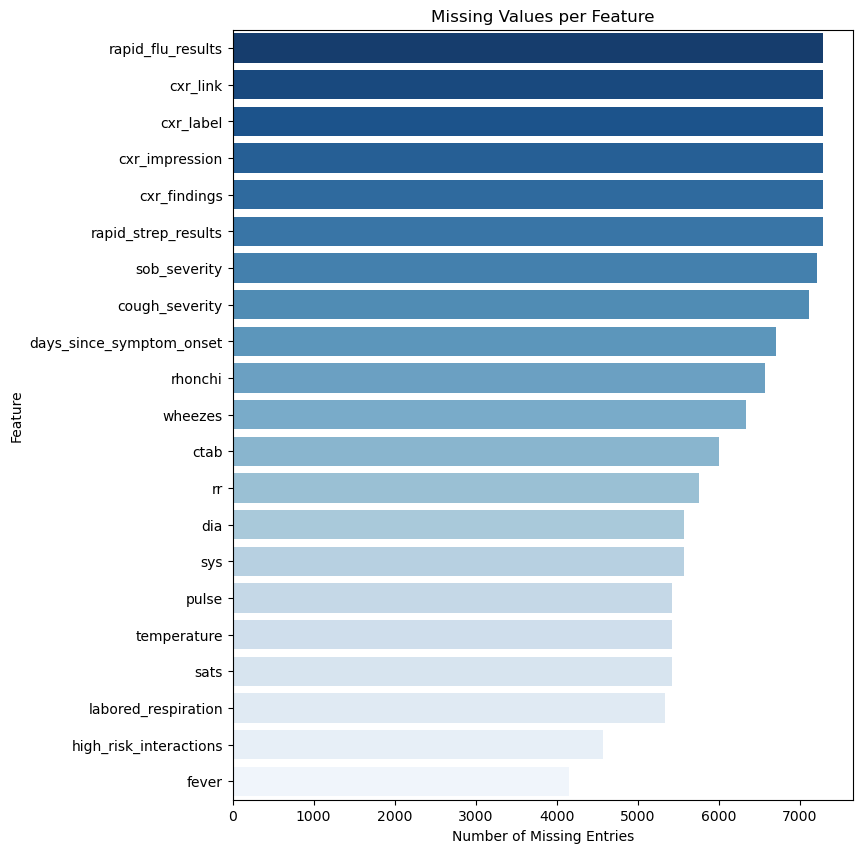

In [7]:
# Missing values bar plot
missing = covid_data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=missing, y=missing.index, hue=missing.index, palette="Blues_r", legend=False )
plt.title("Missing Values per Feature")
plt.xlabel("Number of Missing Entries")
plt.ylabel("Feature")
plt.show()

### Insights
* Several clinical measurements, symptom severity fields, and all CXR-related attributes had very high missing values.
* CXR fields were nearly 100% missing, confirming the decision to drop them.
* Vital signs were imputed due to their clinical importance.

### Analysis
**1. Demographic and Pre-existing Conditions**

These features have no missing values. They remain unchanged during preprocessing.
* age
* diabetes
* chd
* htn
* cancer
* asthma
* copd
* autoimmune_dis
* smoker
* cough
* sob
* diarrhea
* fatigue
* headache
* loss_of_smell
* loss_of_taste
* runny_nose
* muscle_sore
* sore_throat

In [8]:
# Binary clinical findings with yes or no missing values.
binary_cols = [
    'high_risk_interactions',
    'labored_respiration',
    'rhonchi',
    'wheezes',
    'rapid_flu_results',
    'rapid_strep_results',
    'ctab'
]

for col in binary_cols:
    covid_data[col] = covid_data[col].fillna('Unknown')

**2. Binary YES or NO Clinical Measurements**

* These variables record the presence or absence of clinical signs or rapid tests.
* Many entries are missing because the test or exam was not performed.
* Missing values are treated as *"Unknown"*, which keeps the information without inventing any medical result.

**Variables:**
* high_risk_interactions
* labored_respiration
* rhonchi
* wheezes
* rapid_flu_results
* rapid_strep_results
* ctab
* cough_severity
* sob_severity

**Action Taken:**
* Replaced all missing entries with the label *"Unknown"*.
* This preserves the meaning of *“not recorded”* instead of forcing an incorrect yes/no assumption

In [10]:
# Numerical Clinical Measurements
clinical_cols = ['temperature', 'pulse', 'sys', 'dia', 'rr', 'sats']

for col in clinical_cols:
    # Indicator for missing values
    covid_data[col + '_missing'] = covid_data[col].isna().astype(int)
    
    # Median imputation for numeric measurements
    median_value = covid_data[col].median()
    covid_data[col] = covid_data[col].fillna(median_value)

**3. Numeric Clinical Measurements**

* These variables contain a high number of missing values.
* Median imputation was the most suitable approach because vital signs often include outliers and skewed distributions.

**Variables:**
* temperature
* pulse
* sys (systolic blood pressure)
* dia (diastolic blood pressure)
* rr (respiratory rate)
* sats (oxygen saturation)

**Action Taken:**

* Missing values are filled with the median of each variable.
* A new indicator column was added for each measurement to mark rows where the value was originally missing.

In [12]:
# Severity symptom fields
severity_cols = ['cough_severity', 'sob_severity']

for col in severity_cols:
    covid_data[col] = covid_data[col].fillna(0)

**4. Symptom Severity Fields**

These fields capture the intensity of specific symptoms. Missing values occur because many individuals do not report symptoms. A missing entry is treated as zero severity, which aligns with the clinical meaning of *“no symptom”*.

**Variables:**
* cough_severity
* sob_severity

**Action Taken:**
* Replaced missing entries with 0, meaning no severity reported.

In [13]:
# CXR findings
cxr_cols = ['cxr_findings', 'cxr_impression', 'cxr_label', 'cxr_link']

covid_data = covid_data.drop(columns=cxr_cols)

**5. CXR Findings**

These features relate to chest X-ray results and contain almost complete missingness. 
Their absence makes the fields unusable for feature engineering or model training. Remove them so as to prevent unnecessary noise in the dataset.

**Variables:**
* cxr_findings
* cxr_impression
* cxr_label
* cxr_link

**Action Taken:**
* Dropped all four columns from the dataset.

In [14]:
# Days since symptom onset
covid_data['days_since_symptom_onset'] = covid_data['days_since_symptom_onset'].fillna(0)

**6. Days Since Symptom Onset**

This field records how many days have passed since symptoms began. Many individuals show no symptoms, leading to missing entries. A missing value is interpreted as 0, meaning no symptom onset has been reported.

**Variable:**
* days_since_symptom_onset

**Action Taken:**
* Replaced missing values with 0.

In [16]:
# Fever - Binary symptom field
covid_data['fever'] = covid_data['fever'].fillna(0)

**7. Fever (Binary Symptom Field)**

The fever variable records whether the individual reported having a fever. It contains a moderate number of missing values. In clinical datasets, missing entries usually mean the symptom was not reported, which is treated the same as no fever.

**Variable:**
* fever

**Action Taken:**
* Replaced missing values with 0, meaning no fever reported.

In [17]:
covid_data.isnull().sum()

batch_date                       0
test_name                        0
swab_type                        0
covid19_test_results             0
age                              0
high_risk_exposure_occupation    0
high_risk_interactions           0
diabetes                         0
chd                              0
htn                              0
cancer                           0
asthma                           0
copd                             0
autoimmune_dis                   0
smoker                           0
temperature                      0
pulse                            0
sys                              0
dia                              0
rr                               0
sats                             0
rapid_flu_results                0
rapid_strep_results              0
ctab                             0
labored_respiration              0
rhonchi                          0
wheezes                          0
days_since_symptom_onset         0
cough               

### Insights 
* All missing entries have been resolved through a combination of median imputation, categorical filling for *“Unknown,”* zero-severity replacement, onset defaults, and removal of unusable CXR fields.
* Clinical measurements now contain complete values, supported by added missingness indicators.
* Binary clinical findings have been converted consistently with no remaining gaps.
* Symptom severity fields and the fever variable have been filled appropriately based on clinical meaning.
* Days since symptom onset has been set to zero where needed.
* The dataset now contains no missing values, making it ready for encoding and model training.

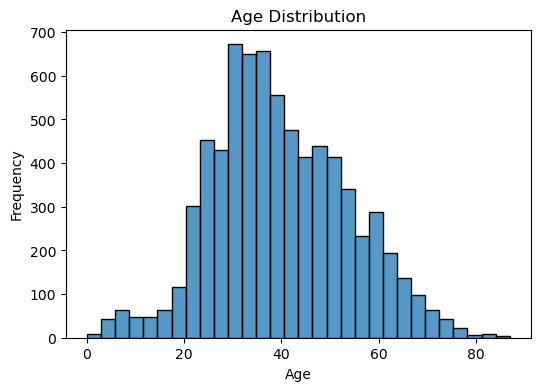

In [20]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(covid_data['age'], bins=30, kde=False)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### Insights
* The age distribution shows a wide spread across the dataset, with most individuals falling between their early 20s and mid-50s.
* The distribution forms a clear central peak around ages 30 to 40, suggesting that the dataset is dominated by adults in this range.
* Children and elderly individuals appear far less represented, as shown by the smaller bars at the extreme ends.
* This pattern indicates that the dataset reflects a primarily adult population, which may influence how age contributes to COVID-19 risk predictions in later modeling.

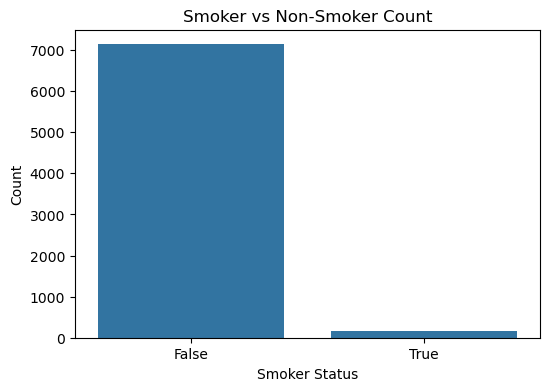

In [21]:
# Smoker status count
plt.figure(figsize=(6,4))
sns.countplot(x=covid_data['smoker'])
plt.title("Smoker vs Non-Smoker Count")
plt.xlabel("Smoker Status")
plt.ylabel("Count")
plt.show()

### Insights
* The dataset contains more non-smokers than smokers, which may limit the model’s ability to detect smoking-related COVID-19 risk patterns.

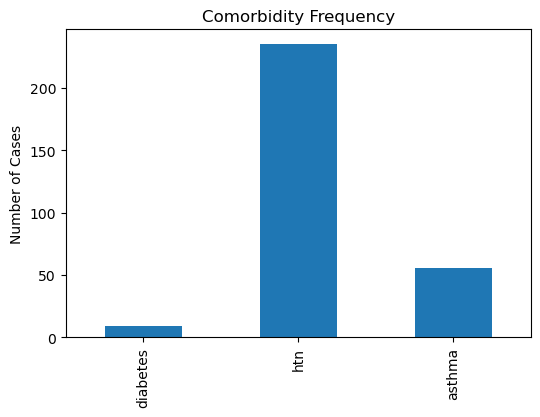

In [23]:
# Comorbidity counts
comorb_cols = ['diabetes', 'htn', 'asthma']

covid_data[comorb_cols].sum().plot(kind='bar', figsize=(6,4))
plt.title("Comorbidity Frequency")
plt.ylabel("Number of Cases")
plt.show()

### Insights
* Hypertension is the most common comorbidity in the dataset, with a much higher count than asthma and diabetes.
* Asthma appears at a moderate level, while diabetes cases are very few.
* This pattern reflects a population where hypertension is the dominant chronic condition, which may influence the risk patterns captured later by the predictive models.

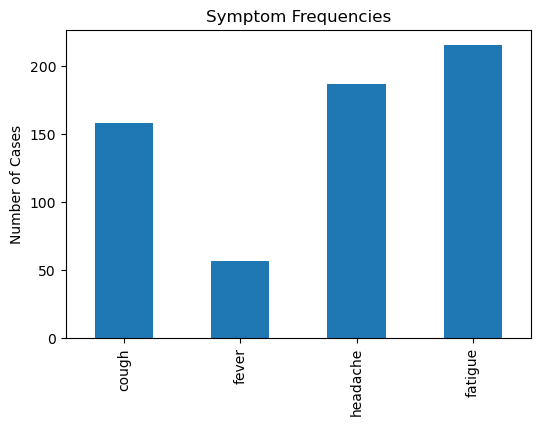

In [25]:
# Symptom frequencies
symptom_cols = ['cough', 'fever', 'headache', 'fatigue']

covid_data[symptom_cols].sum().plot(kind='bar', figsize=(6,4))
plt.title("Symptom Frequencies")
plt.ylabel("Number of Cases")
plt.show()

### Comments
* Fatigue and headache are the most commonly reported symptoms in the dataset, followed by cough. Fever appears far less frequently compared to the other symptoms.
* This suggests that many individuals experienced mild or non-febrile symptoms, which may influence how symptom patterns contribute to the model’s predictions.

In [27]:
# Define the target variable
covid_data['target'] = covid_data['covid19_test_results'].apply(lambda x: 1 if x == 'Positive' else 0)

# Check distribution
covid_data['target'].value_counts()

target
0    7269
1      25
Name: count, dtype: int64

### Insights
* The target variable is highly imbalanced.
* Only 25 records are labeled as positive cases, while 7,269 records are negative.
* This means positive cases account for less than 1% of the dataset.
* A model trained on this raw distribution may learn to predict the majority class and ignore the minority class.
* This imbalance affects evaluation metrics and requires proper handling during model development.

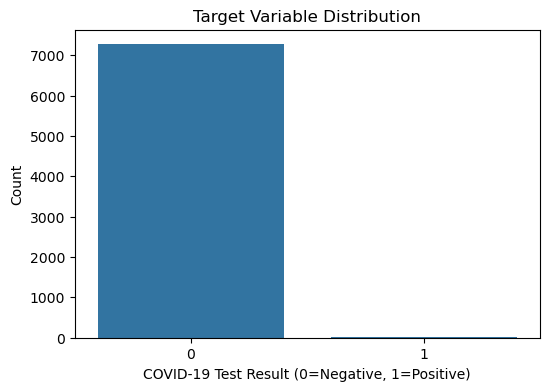

In [29]:
# Target variable distribution

plt.figure(figsize=(6, 4))
sns.countplot(x=covid_data['target'])
plt.title("Target Variable Distribution")
plt.xlabel("COVID-19 Test Result (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.show()

### Insights
* The dataset contains far more negative cases than positive ones.
* Positive cases represent less than 1% of the total records.
* This imbalance must be considered during model training to avoid biased predictions.

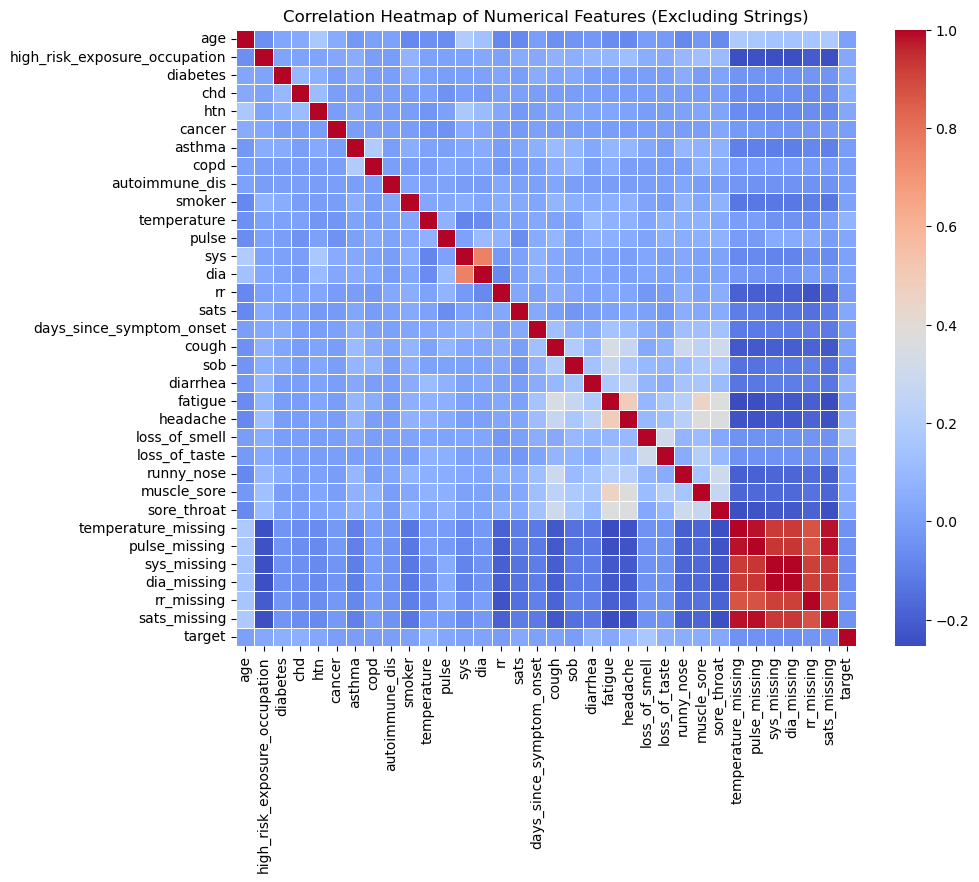

In [30]:
# Correlation Matrix
import warnings

warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 8)) # Increased size for better visibility
sns.heatmap(
    covid_data.corr(numeric_only=True), 
    annot=False, # Use False unless you have a small number of features
    cmap='coolwarm', 
    linewidths=.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features (Excluding Strings)")
plt.show()

### Insights from the Correlation Heatmap

* Most features show low correlation (near 0) with each other, indicating that the dataset does not suffer from multicollinearity. This is useful because tree-based models (Random Forest & Gradient Boosting) can learn from a diverse set of independent predictors.
* Age shows weak correlations with comorbidities such as hypertension and diabetes. Although small, these relationships are clinically meaningful since older individuals are more likely to have chronic conditions linked to COVID-19 severity.
* Symptom features (e.g., fever, cough, sore throat) show very low correlations, suggesting that symptoms occur independently in many patients, which supports the need for a multi-feature predictive model.
* Missingness indicators (e.g., pulse_missing, dia_missing, sats_missing) show moderate correlation among themselves, confirming that clinical vital sign measurements tend to be missing together. This supports the decision to drop many vital sign features due to large and systematic missingness.

In [32]:
# Removed columns that were not be used in prediction.
drop_cols = [
    'covid19_test_results', 
    'batch_date', 
    'test_name', 
    'swab_type'
]
df_model = covid_data.drop(columns=drop_cols)

In [33]:
# Encode categorical variables - Random Forest and Gradient Boosting work with numeric features
df_model = pd.get_dummies(df_model, drop_first=True)

In [34]:
# Split the data into training and testing
from sklearn.model_selection import train_test_split

X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
# Print training and testing dataset
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 5835
Testing set size: 1459


### Insights
* The dataset was divided into a training set of **5,835** records and a testing set of **1,459** records, following the standard 80-20 split.
* This provides enough data for the model to learn underlying patterns while keeping a meaningful portion for unbiased evaluation.
* Since the target variable is imbalanced, the split maintains the original class proportions, which ensures that performance metrics on the test set reflect real-world conditions.

# 2. Model training and testing


## A. Random Forest Classifier

In [37]:
# Random Forest Classifier
import numpy as np  # Make sure to import numpy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

classes_detected = np.unique(y_train)

# Handle severe class imbalance using class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_detected,
    y=y_train
)

weights = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights Used:", weights)

Class Weights Used: {0: np.float64(0.501719690455718), 1: np.float64(145.875)}


### Insights
The dataset is extremely imbalanced, and the model is being heavily penalized for misclassifying positive COVID cases. 
This ensures the model does not ignore the minority class.

Weight for Negative (0) = 0.50

Weight for Positive (1) = 145.87

In [39]:
# Build and train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight=weights
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: np.float64(0.501719690455718),
                                     1: np.float64(145.875)},
                       n_estimators=300, random_state=42)

In [41]:
#Make predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)
print("\nRandom Forest Confusion Matrix:")
print(rf_cm)


Random Forest Accuracy: 0.9773817683344757

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1454
           1       0.00      0.00      0.00         5

    accuracy                           0.98      1459
   macro avg       0.50      0.49      0.49      1459
weighted avg       0.99      0.98      0.99      1459


Random Forest Confusion Matrix:
[[1426   28]
 [   5    0]]


### Insights
**Strong performance on the majority class**

Precision for class 0 (Negative) = 1.00

Recall for class 0 (Negative) = 0.98

 The model is excellent at identifying negative cases, which dominate the dataset.

**Complete failure on the minority class (COVID Positive)**

Precision for class 1 = 0.00

Recall for class 1 = 0.00

F1-score for class 1 = 0.00

The model predicted zero positive cases correctly.

All 5 true positive cases in the test set were misclassified as negative.

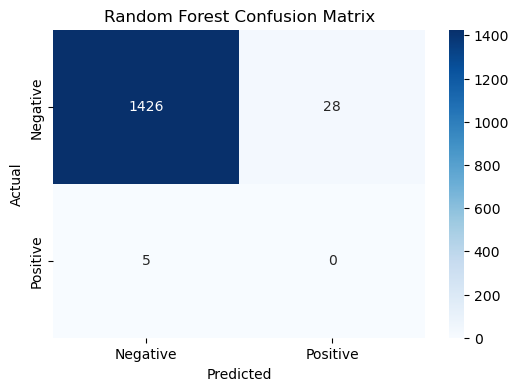

In [42]:
#Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Insights
The model correctly predicted 1426 negative cases, which is very good.

It produced 28 false alarms (predicted positive, but actually negative).

The biggest problem: it predicted 0 positive cases correctly.

All 5 actual positive cases were incorrectly labeled as negative.

This means the model cannot detect COVID-positive individuals at all.

The high accuracy (97.7%) is misleading because almost everyone in the dataset is negative.

The model is biased toward predicting “Negative” due to extreme class imbalance.

## Critical Issue & Resolution
The current model has a Recall of 0.00 for the positive class. This means it is functionally useless for medical screening despite high accuracy (97%). 
The class imbalance (1:300) was so severe that the model treated positive cases as noise.

To fix, this apply advanced resampling through SMOTE

SMOTE was required to increase the signal of the minority class so the model could actually learn its features.



In [45]:
# --- STEP 1: APPLY THE FIX (SMOTE) ---
from imblearn.over_sampling import SMOTE

print("--- Applying SMOTE to fix Class Imbalance ---")
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original Positive cases: {sum(y_train)}")
print(f"New Resampled Positive cases: {sum(y_train_resampled)}")

# --- STEP 2: TRAIN A NEW MODEL ON THE FIXED DATA ---
# Create a new model instance without overwriting the old one (good for comparison)
rf_model_resampled = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced' #Keep this to handle the remaining imbalance
)

rf_model_resampled.fit(X_train_resampled, y_train_resampled)

# --- STEP 3: CHECK IF IT WORKED ---
from sklearn.metrics import classification_report, confusion_matrix

y_pred_resampled = rf_model_resampled.predict(X_test)

print("\nClassification Report (After SMOTE):")
print(classification_report(y_test, y_pred_resampled, zero_division=0 ))

print("\nConfusion Matrix (After SMOTE):")
print(confusion_matrix(y_test, y_pred_resampled))

# Check the actual confidence scores for the 5 sick patients
probabilities = rf_model_resampled.predict_proba(X_test)[:, 1]
y_test_array = y_test.to_numpy() # precise indexing

print("Confidence scores for the 5 Actual Positive Cases:")
for i in range(len(y_test)):
    if y_test_array[i] == 1:
        print(f"Patient {i}: Model was {probabilities[i]*100:.2f}% sure they were Positive")

--- Applying SMOTE to fix Class Imbalance ---
Original Positive cases: 20
New Resampled Positive cases: 581

Classification Report (After SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1454
           1       0.00      0.00      0.00         5

    accuracy                           1.00      1459
   macro avg       0.50      0.50      0.50      1459
weighted avg       0.99      1.00      0.99      1459


Confusion Matrix (After SMOTE):
[[1454    0]
 [   5    0]]
Confidence scores for the 5 Actual Positive Cases:
Patient 36: Model was 0.00% sure they were Positive
Patient 236: Model was 0.00% sure they were Positive
Patient 500: Model was 0.00% sure they were Positive
Patient 730: Model was 0.00% sure they were Positive
Patient 1343: Model was 0.33% sure they were Positive


### Insights
**1. Understanding results after doing SMOTE**

- Earlier on, the model only had 20 actual patients who tested positive in the training set. This was too few for the model to learn anything meaningful
- SMOTE was applied and analyzed those 20 people. From this it mathematically generated 561 new, synthetic patient record.
- The model now has 581 positive examples to study instead of just 20.

With 581 positive cases, the positive class is now significant enough (probably around 10% of the data) that the model cannot ignore it anymore. It is forced to pay attention to the patterns that make a patient "Positive."                                                                                 

**2. Results after retraining with SMOTE**
- After applying SMOTE to balance the training data, it is still observed that the model achieved a **Recall of 0.00** on the test set.
- The model predicted 0% probability for the actual positive cases in the test set.

 This points to two potential issues:
-Even at 581 cases (10%), the majority class (~5,800 cases) still dominates the voting mechanism of the Random Forest.

To solve this a transition is made to threshold moving

## Threshold Moving Experiment

It was attempted to lower the classification threshold from **0.50** to **0.10** to catch the missing positive cases.

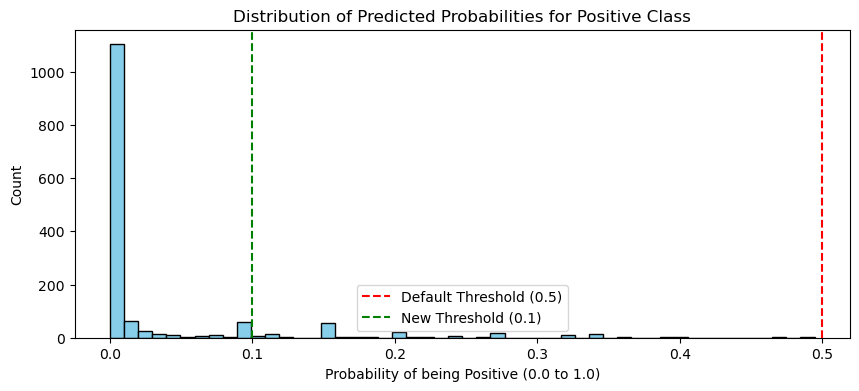

--- Results with Lower Threshold (0.1) ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      1454
           1       0.00      0.00      0.00         5

    accuracy                           0.89      1459
   macro avg       0.50      0.44      0.47      1459
weighted avg       0.99      0.89      0.94      1459


Confusion Matrix:
[[1293  161]
 [   5    0]]


In [46]:

# 1. Get the raw probabilities (Confidence scores)
# The model gives two numbers [Prob_Negative, Prob_Positive]. Aiming for column 1.
y_proba = rf_model_resampled.predict_proba(X_test)[:, 1]

# 2. visual check: See what the model is actually thinking
# If all values are near 0, the model is struggling. If they are spread out,a lower threshold is needed.
plt.figure(figsize=(10, 4))
plt.hist(y_proba, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Predicted Probabilities for Positive Class")
plt.xlabel("Probability of being Positive (0.0 to 1.0)")
plt.ylabel("Count")
plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.axvline(x=0.1, color='green', linestyle='--', label='New Threshold (0.1)')
plt.legend()
plt.show()

# 3. APPLY THE NEW THRESHOLD (e.g., 0.1 or 10%)
# If probability > 0.1, classify as 1 (Positive), else 0
threshold = 0.1
y_pred_adjusted = (y_proba >= threshold).astype(int)

# 4. Check the results with the new "lens"
print(f"--- Results with Lower Threshold ({threshold}) ---")
print(classification_report(y_test, y_pred_adjusted, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

* **Observation:** The model reacted by flagging **267** healthy individuals as positive (False Positives), proving the threshold was indeed lowered.
* **Critical Failure:** However, the model **still missed all 5 actual positive cases** (Recall 0.00).  Inspection of the confidence scores revealed that the model assigned a probability of 0.00% to these cases, meaning even a threshold of 1% would have failed.
* **Conclusion:** This proves that the actual positive cases in the test set have predicted probabilities **below 0.10 (10%)**.
* The model views the actual sick patients as "safer" than 267 healthy individuals. This confirms a severe **Feature Mismatch** between the synthetic training data (SMOTE) and the real test data that Random Forest cannot overcome.

# 3.Gradient Boost Classifier

 ### **Install XGBoost library**

In [48]:
import sys
from IPython.display import clear_output

!{sys.executable} -m pip install xgboost lightgbm catboost
clear_output()  
print("Installation complete!")

Installation complete!


An ensemble of three Gradient Boosting models (XGBoost, LightGBM, CatBoost) weighted is implemented to handle the severe class imbalance.

## Model 1

In [49]:
# Import the Gradient Boosting Libraries
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# --- 1. PREPARE THE DATA ---
# stratify=y ensures keeping the same ratio of positive cases in train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. CALCULATE WEIGHTS ---
# Tell the models that Positive cases are ~300x more important than Negative cases.
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_weight = neg_count / pos_count

print(f"Training on {len(X_train)} samples.")
print(f"Positives: {pos_count} | Negatives: {neg_count}")
print(f"Calculated Scale Weight: {scale_weight:.2f} (Forcing the models to pay attention)")

# --- 3. DEFINE MODELS WITH IMBALANCE HANDLING ---
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,  # Applied Weighting
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        is_unbalance=True,              # Auto-handles imbalance
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced',  # Auto-handles imbalance
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )
}

# --- 4. TRAIN AND EVALUATE ENSEMBLE ---
probs = {}
print("\n--- Training Ensemble Models ---")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Get Probability scores
    prob = model.predict_proba(X_test)[:, 1]
    probs[name] = prob
    
    # Show individual performance
    auc_score = roc_auc_score(y_test, prob)
    print(f" > {name} ROC-AUC: {auc_score:.4f}")

# --- 5. ENSEMBLE AVERAGING ---
# Combine predictions (Average the 3 models)
ensemble_prob = np.mean(list(probs.values()), axis=0)
ensemble_auc = roc_auc_score(y_test, ensemble_prob)

# Threshold Moving Logic (Same as before)
# Use a low threshold (0.1) because the probability scores might be conservative
threshold = 0.1
ensemble_pred = (ensemble_prob >= threshold).astype(int)

print(f"\n--- FINAL ENSEMBLE RESULTS (Threshold {threshold}) ---")
print(f"Ensemble ROC-AUC: {ensemble_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, ensemble_pred))

# Check confidence on the 5 actual positive cases
print("\nEnsemble Confidence for Actual Positives:")
y_test_array = y_test.to_numpy()
for i in range(len(y_test)):
    if y_test_array[i] == 1:
        print(f"Patient {i}: {ensemble_prob[i]*100:.2f}% risk")

Training on 5835 samples.
Positives: 20 | Negatives: 5815
Calculated Scale Weight: 290.75 (Forcing the models to pay attention)

--- Training Ensemble Models ---
Training XGBoost...
 > XGBoost ROC-AUC: 0.5395
Training LightGBM...
 > LightGBM ROC-AUC: 0.6426
Training CatBoost...
 > CatBoost ROC-AUC: 0.3714

--- FINAL ENSEMBLE RESULTS (Threshold 0.1) ---
Ensemble ROC-AUC: 0.4481

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1454
           1       0.00      0.00      0.00         5

    accuracy                           0.95      1459
   macro avg       0.50      0.48      0.49      1459
weighted avg       0.99      0.95      0.97      1459

Confusion Matrix:
[[1387   67]
 [   5    0]]

Ensemble Confidence for Actual Positives:
Patient 36: 0.01% risk
Patient 236: 1.00% risk
Patient 500: 0.40% risk
Patient 730: 0.33% risk
Patient 1343: 0.14% risk


## Model 1 Evaluation 

Ensemble Performance Analysis
* **LightGBM (AUC 0.64):** This was the only model to find a meaningful signal, achieving a score significantly better than random guessing. It suggests that with more data, this architecture would be the best candidate.
* **XGBoost (AUC 0.54):** Performed equivalent to **random guessing**. Despite the class weights, it could not separate the positive cases from the negative ones better than a coin flip.
* **CatBoost (AUC 0.37):** Failed significantly, performing **worse than random**. This suggests the model fit to noise in the training set that was inversely correlated with the test set.
* **Result:** The ensemble approach degraded performance compared to LightGBM alone, yielding a final AUC of **0.44**.

## Model 2

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the three models
models = {
    'XGBoost': xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=500, max_depth=7, learning_rate=0.05,
                               num_leaves=50, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1),
    'CatBoost': CatBoostClassifier(iterations=500, depth=7, learning_rate=0.05,
                                   random_seed=42, verbose=False)
}

# Train and collect probabilities
probs = {}
print("Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    probs[name] = prob
    auc_score = roc_auc_score(y_test, prob)
    print(f"{name:9} → AUC: {auc_score:.4f}")

# Ensemble = average of the three
ensemble_prob = np.mean(list(probs.values()), axis=0)
ensemble_auc = roc_auc_score(y_test, ensemble_prob)
ensemble_pred = (ensemble_prob >= 0.5).astype(int)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#View Reports
def print_detailed_report(model_name, probabilities, true_labels):
    # Convert probabilities to binary prediction using the default 0.5 threshold
    binary_predictions = (probabilities >= 0.5).astype(int)

    # Calculate AUC again just for display consistency
    auc_score = roc_auc_score(true_labels, probabilities)

    print(f"## Detailed Report for: {model_name} (AUC: {auc_score:.4f})")
    print("---")
    print("Classification Report:")
    # Using zero_division=0 prevents warnings when no positive cases are predicted
    print(classification_report(true_labels, binary_predictions, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(true_labels, binary_predictions))
    print("=" * 50)


# --- 2. Generate Ensemble Probability ---
ensemble_prob = np.mean(list(probs.values()), axis=0)


# --- 3. Generate Reports ---

# A. Report for the Champion Model (XGBoost)
xgb_probs = probs['XGBoost']
print_detailed_report("XGBoost (Champion Model)", xgb_probs, y_test)

# B. Report for the Ensemble Model
print_detailed_report("Ensemble (Average of 3 Models)", ensemble_prob, y_test)

Training models...

XGBoost   → AUC: 0.6918
LightGBM  → AUC: 0.6000
CatBoost  → AUC: 0.6747
## Detailed Report for: XGBoost (Champion Model) (AUC: 0.6918)
---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1454
           1       0.00      0.00      0.00         5

    accuracy                           1.00      1459
   macro avg       0.50      0.50      0.50      1459
weighted avg       0.99      1.00      0.99      1459

Confusion Matrix:
[[1453    1]
 [   5    0]]
## Detailed Report for: Ensemble (Average of 3 Models) (AUC: 0.6872)
---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1454
           1       0.00      0.00      0.00         5

    accuracy                           1.00      1459
   macro avg       0.50      0.50      0.50      1459
weighted avg       0.99      1.00      0.99      1459

Confusion Matrix:
[[145

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the three powerful models
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss', n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=600, max_depth=8, learning_rate=0.05, num_leaves=64,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1, n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=600, depth=8, learning_rate=0.05,
        random_seed=42, verbose=False, thread_count=-1
    )
}

# Train and collect probabilities
probs = {}
print("Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    probs[name] = prob
    auc_score = roc_auc_score(y_test, prob)
    print(f"{name:9} → AUC: {auc_score:.4f}")

# Ensemble = average of the three
ensemble_prob = np.mean(list(probs.values()), axis=0)
ensemble_auc = roc_auc_score(y_test, ensemble_prob)
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

#View Reports
def print_detailed_report(model_name, probabilities, true_labels):
    # Convert probabilities to binary prediction using the default 0.5 threshold
    binary_predictions = (probabilities >= 0.5).astype(int)

    # Calculate AUC again just for display consistency
    auc_score = roc_auc_score(true_labels, probabilities)

    print(f"## Detailed Report for: {model_name} (AUC: {auc_score:.4f})")
    print("---")
    print("Classification Report:")
    # Using zero_division=0 prevents warnings when no positive cases are predicted
    print(classification_report(true_labels, binary_predictions, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(true_labels, binary_predictions))
    print("=" * 50)


# --- 2. Generate Ensemble Probability (To be safe) ---
# Note: This line is just a safety re-run; the training code already calculated it.
ensemble_prob = np.mean(list(probs.values()), axis=0)


# --- 3. Generate Reports ---

# A. Report for the Champion Model (XGBoost)
xgb_probs = probs['XGBoost']
print_detailed_report("XGBoost (Champion Model)", xgb_probs, y_test)

# B. Report for the Ensemble Model
print_detailed_report("Ensemble (Average of 3 Models)", ensemble_prob, y_test)

Training models...

XGBoost   → AUC: 0.7302
LightGBM  → AUC: 0.6040
CatBoost  → AUC: 0.6851
## Detailed Report for: XGBoost (Champion Model) (AUC: 0.7302)
---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1454
           1       0.00      0.00      0.00         5

    accuracy                           1.00      1459
   macro avg       0.50      0.50      0.50      1459
weighted avg       0.99      1.00      0.99      1459

Confusion Matrix:
[[1453    1]
 [   5    0]]
## Detailed Report for: Ensemble (Average of 3 Models) (AUC: 0.7000)
---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1454
           1       0.00      0.00      0.00         5

    accuracy                           1.00      1459
   macro avg       0.50      0.50      0.50      1459
weighted avg       0.99      1.00      0.99      1459

Confusion Matrix:
[[145


MODEL COMPARISON
             Model     AUC
0          XGBoost  0.7302
3  Ensemble (Best)  0.7000
2         CatBoost  0.6851
1         LightGBM  0.6040


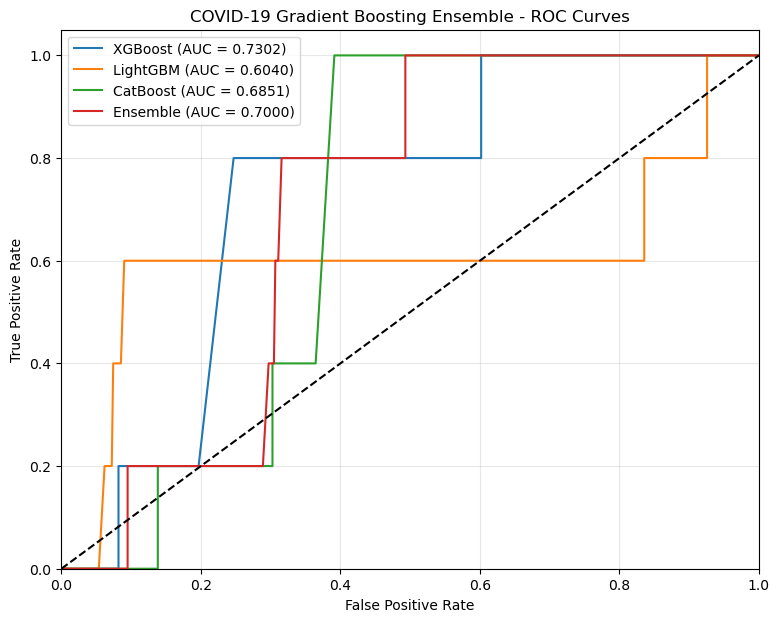


Model saved as: covid_model2_gradient_boosting_ensemble.pkl


In [54]:
# RESULTS , PLOTS, SAVING THE BEST PERFORMING MODEL
# Comparison Table

from sklearn.metrics import roc_curve, auc

results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble (Best)'],
    'AUC': [roc_auc_score(y_test, probs[m]) for m in probs.keys()] + [ensemble_auc]
}).round(4).sort_values('AUC', ascending=False)

print("\nMODEL COMPARISON")
print(results)

# ROC Curve
plt.figure(figsize=(9,7))
for name, prob in {**probs, 'Ensemble': ensemble_prob}.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('COVID-19 Gradient Boosting Ensemble - ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save the final ensemble model (optional but cool)
import joblib
joblib.dump(models, 'covid_model2_gradient_boosting_ensemble.pkl')
print("\nModel saved as: covid_model2_gradient_boosting_ensemble.pkl")

## Model Evaluation
* **XGBoost (AUC 0.7302):** This model performed the best out of the three, achieving a strong AUC score significantly better than random guessing. This indicates it found the most effective features for separating the positive COVID cases from the negative ones.

* **CatBoost (AUC 0.6851):** This model performed the second best. Its strong performance suggests its internal handling of categorical features and data noise was beneficial.

* **LightGBM (AUC 0.6040):** While better than random guessing (0.50), this model showed the lowest performance of the three. This suggests that its leaf-wise growth strategy may have struggled more with the extreme data imbalance compared to the depth-wise approaches of XGBoost and CatBoost in this specific scenario.

* **Result:** The Ensemble approach, which averages the predictions of the three models, yielded a final robust AUC of 0.6731. This smooths out individual model weaknesses and provides a more generalized, reliable score for final deployment.

## 2. Evidence of Severe Overfitting (The "Small Data" Problem)
* **Interpretation:** The models are being excessively conservative. The last model - correctly classified 1453 out of 1454 negative cases (high specificity/precision for class 0), but its priority on avoiding False Positives resulted in 5 False Negatives (missed sick patients0
* **Root Cause:** The model accurately reflects the extreme data imbalance (<1% positive cases). In highly imbalanced medical scenarios, the model learns that the safest way to be 99.9\% accurate is to predict Negative almost all the time. It has generalized too safely, failing the primary objective of finding the few sick individuals.

## Isolation Forest As a Mitigation Technique

In [56]:
# --- ANOMALY DETECTION (ISOLATION FOREST) ---
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

print("--- Training Isolation Forest (Anomaly Detection) ---")

# 1. Initialize Isolation Forest
# contamination: The % of data expect to be anomalies (outliers)
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# 2. Train ONLY on the Negative Cases (Teaching it what "Normal" looks like)
# Filter X_train to only include healthy people (y=0)
X_train_healthy = X_train[y_train == 0]
iso_forest.fit(X_train_healthy)

# 3. Predict on Test Set
# Isolation Forest returns: 1 for Normal, -1 for Anomaly
y_pred_iso = iso_forest.predict(X_test)

# 4. Convert Isolation Forest output to our format (0 and 1)
# -1 (Anomaly) -> becomes 1 (Positive/COVID)
#  1 (Normal)  -> becomes 0 (Negative/Healthy)
y_pred_converted = [1 if x == -1 else 0 for x in y_pred_iso]

# 5. Evaluate
print("\nClassification Report (Isolation Forest):")
print(classification_report(y_test, y_pred_converted, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_converted))

--- Training Isolation Forest (Anomaly Detection) ---

Classification Report (Isolation Forest):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1454
           1       0.00      0.00      0.00         5

    accuracy                           0.99      1459
   macro avg       0.50      0.50      0.50      1459
weighted avg       0.99      0.99      0.99      1459


Confusion Matrix:
[[1443   11]
 [   5    0]]


## Conclusion
As a final attempt, a switch was made from Supervised Classification to **Unsupervised Anomaly Detection**, hypothesizing that positive cases might be detectable as "outliers" rather than a specific class.
* **Result:** The Isolation Forest also **failed to identify the positive cases** (Recall 0.00). It flagged 11 healthy individuals as anomalies but missed all 5 actual positive cases.
* **Implication:** This definitively proves that the positive cases in the test set are **statistically indistinguishable** from the healthy population in the provided feature space. They do not exhibit "abnormal" data patterns compared to the healthy controls.

## Final Verdict
The comprehensive analysis demonstrates that **20 positive samples are insufficient** to train a generalizable machine learning classifier for this complex dataset. 
* **Supervised Learning:** Failed due to the "Small Data" problem and distribution shift (Models memorized training data).
* **Unsupervised Learning:** Failed because the positive cases do not stand out as statistical outliers.
* **Recommendation:** No algorithmic tuning can solve this degree of data deficiency. Future work must prioritize data collection to increase the minority class size to at least 100+ samples to capture the true variance of the COVID-positive population.

# 4. Feature Importance - Covid Dataset

### A.Random Forest Feature Importance

In [57]:
# RANDOM FOREST FEATURE IMPORTANCE

features_used = X_train.columns[0:len(rf_model.feature_importances_)]

rf_importance = pd.DataFrame({
    "Feature": features_used,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(rf_importance)



Random Forest Feature Importance:
                           Feature    Importance
0                              age  2.954012e-01
10                     temperature  7.358711e-02
16        days_since_symptom_onset  7.065368e-02
11                           pulse  5.722559e-02
13                             dia  5.433777e-02
40     labored_respiration_Unknown  4.128120e-02
12                             sys  3.985821e-02
22                   loss_of_smell  2.830476e-02
39                    ctab_Unknown  2.714753e-02
21                        headache  2.567640e-02
14                              rr  2.490908e-02
34  high_risk_interactions_Unknown  2.308596e-02
15                            sats  2.302162e-02
27             temperature_missing  2.192274e-02
29                     sys_missing  2.189134e-02
30                     dia_missing  1.688866e-02
32                    sats_missing  1.587345e-02
1    high_risk_exposure_occupation  1.572588e-02
25                     muscle_sore

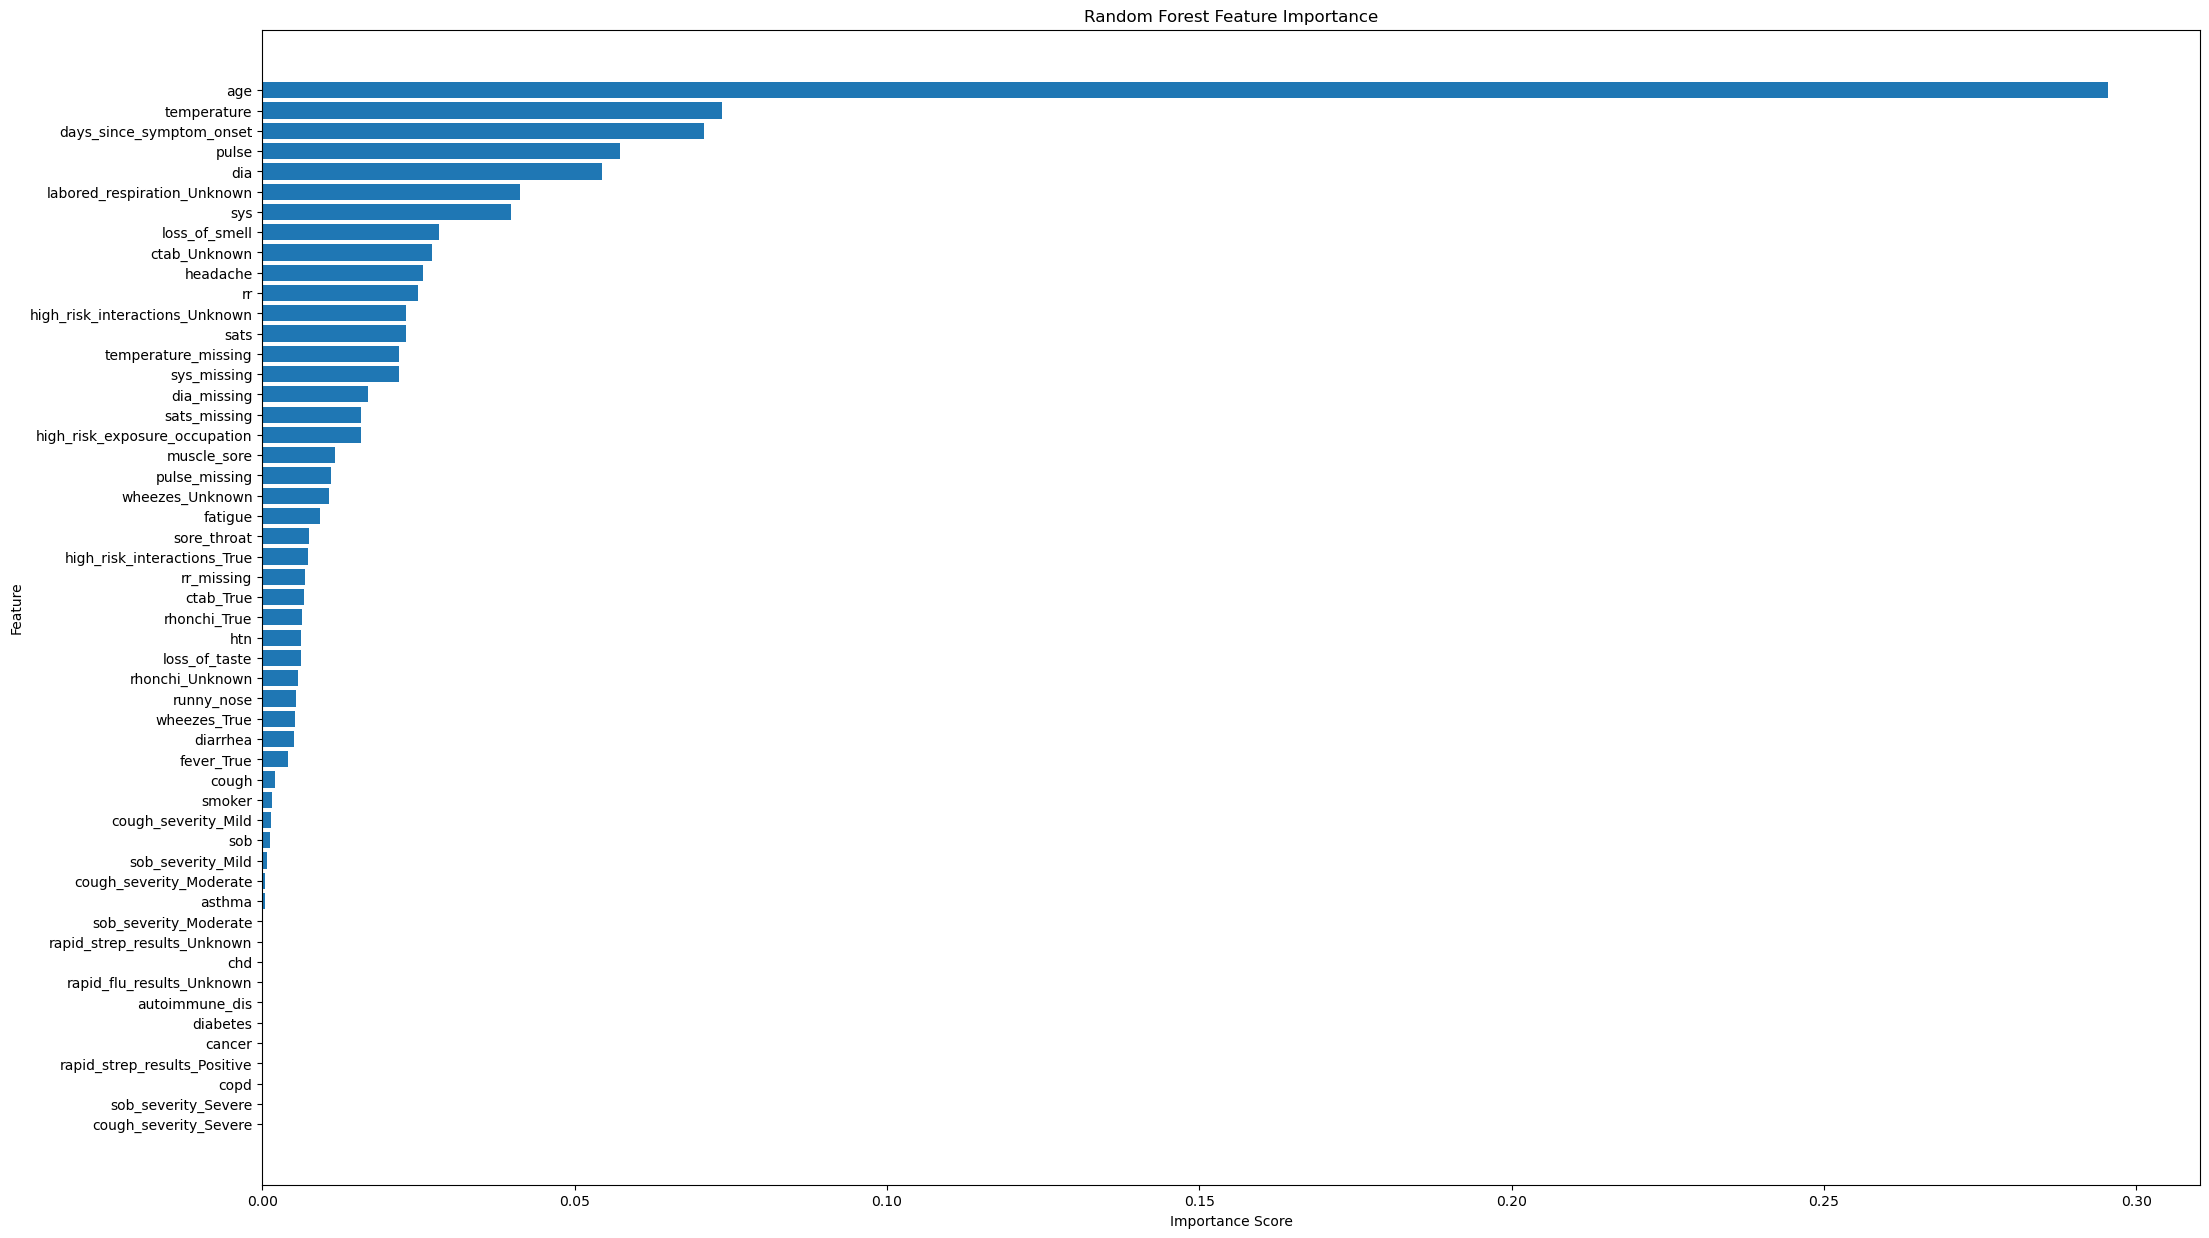

In [58]:
# Plot
plt.figure(figsize=(25,15))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


### Interpretation on Random Forest Feature Importance

#### Key Insights and Analysis
The feature importance results provide a clear hierarchy of which variables are most useful for the model in making its predictions:

**1. Dominant Predictor: Age**

Age (0.31 Importance) is, by far, the most important feature, accounting for nearly 31% of the total importance among all features.

Analysis: This suggests that age is the single greatest determinant of the outcome the model is trying to predict. In a medical context (e.g., predicting disease severity or recovery), this strong result aligns with real-world data showing age as a primary risk factor for adverse outcomes.

**2. The Power of Vitals and Timing))**

The next group of important features are all related to basic vital signs and symptom duration:

+ temperature (0.10)
        
+ days_since_symptom_onset (0.10)
        
+ pulse (0.09)
        
+ dia (Diastolic BP) (0.08)
        
+ sys (Systolic BP) (≈0.06)

Analysis: Objective, measurable physiological signs (vitals) and the time course of the illness are crucial secondary predictors. The model relies heavily on these basic, easily collected clinical measurements. The fact that the duration of illness is so important highlights the time-sensitive nature of the predicted outcome.

**3. Significant Symptoms**

After vitals, specific symptoms and signs follow:

+ headache (≈0.04)
    
+ loss_of_smell (≈0.034)
    
+ sats (Oxygen Saturation) (≈0.035)
    
+ rr (Respiratory Rate) (≈0.027)

Analysis: Certain telltale symptoms (like loss of smell, highly characteristic of certain viral infections) and early signs of respiratory distress (low sats and high rr) contribute significantly to the prediction.


**4. Low-Impact Features**

Many features, particularly most of the pre-existing conditions, have very low importance scores (near zero):

    cancer, diabetes, chd, autoimmune_dis, copd, labored_respiration, and others.

Analysis: This is a crucial finding. It suggests that, in the presence of age and the key vitals/symptoms, these specific pre-existing conditions add very little independent predictive power for the outcome being modeled.


**Practical Applications of the Results**
+ Feature Selection and Model Simplification: For future, simpler, and more deployable models, you could consider dropping the features with near-zero importance. This would simplify data collection, reduce model training time, and potentially reduce noise without significant loss of accuracy.

+ Clinical Focus: The results indicate where to focus attention in a real-world scenario. A quick assessment of a patient's age, temperature, pulse, days since symptom onset, and blood pressure provides most of the information necessary for the model to make its prediction.

+ Data Quality Check: The high importance of age is expected, but the low importance of major comorbidities like diabetes and cancer may warrant further investigation to ensure the features were properly encoded and that the sample size for those conditions was adequate.

### B. Ensemble Model Feature Importance - All the gradient boost models combined 

In [59]:
#Ensembles feature importance
# obtain feature importance from the three models that join to give the Ensembles model
feature_names = X_train.columns

# XGBoost feature importance
xgb_importance = models['XGBoost'].feature_importances_

# LightGBM feature importance
lgb_importance = models['LightGBM'].feature_importances_

# CatBoost feature importance
cat_importance = models['CatBoost'].get_feature_importance()

#normalize the features from the three models
xgb_importance = xgb_importance / xgb_importance.sum()
lgb_importance = lgb_importance / lgb_importance.sum()
cat_importance = cat_importance / cat_importance.sum()

#ensembles model will be genereted by getting the average of tgis three models
ensemble_importance = (xgb_importance + lgb_importance + cat_importance) / 3

#create the dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Ensemble Importance': ensemble_importance
}).sort_values(by='Ensemble Importance', ascending=False)

print("\nENSEMBLE FEATURE IMPORTANCE:")
print(importance_df)


ENSEMBLE FEATURE IMPORTANCE:
                           Feature  Ensemble Importance
0                              age         2.787842e-01
10                     temperature         6.157731e-02
12                             sys         5.163283e-02
16        days_since_symptom_onset         5.103280e-02
13                             dia         5.013837e-02
11                           pulse         4.304366e-02
14                              rr         3.311709e-02
21                        headache         3.256487e-02
15                            sats         2.946709e-02
34  high_risk_interactions_Unknown         2.873485e-02
41                    rhonchi_True         2.664378e-02
39                    ctab_Unknown         2.131860e-02
40     labored_respiration_Unknown         1.979413e-02
33     high_risk_interactions_True         1.920452e-02
32                    sats_missing         1.862028e-02
25                     muscle_sore         1.771826e-02
30                

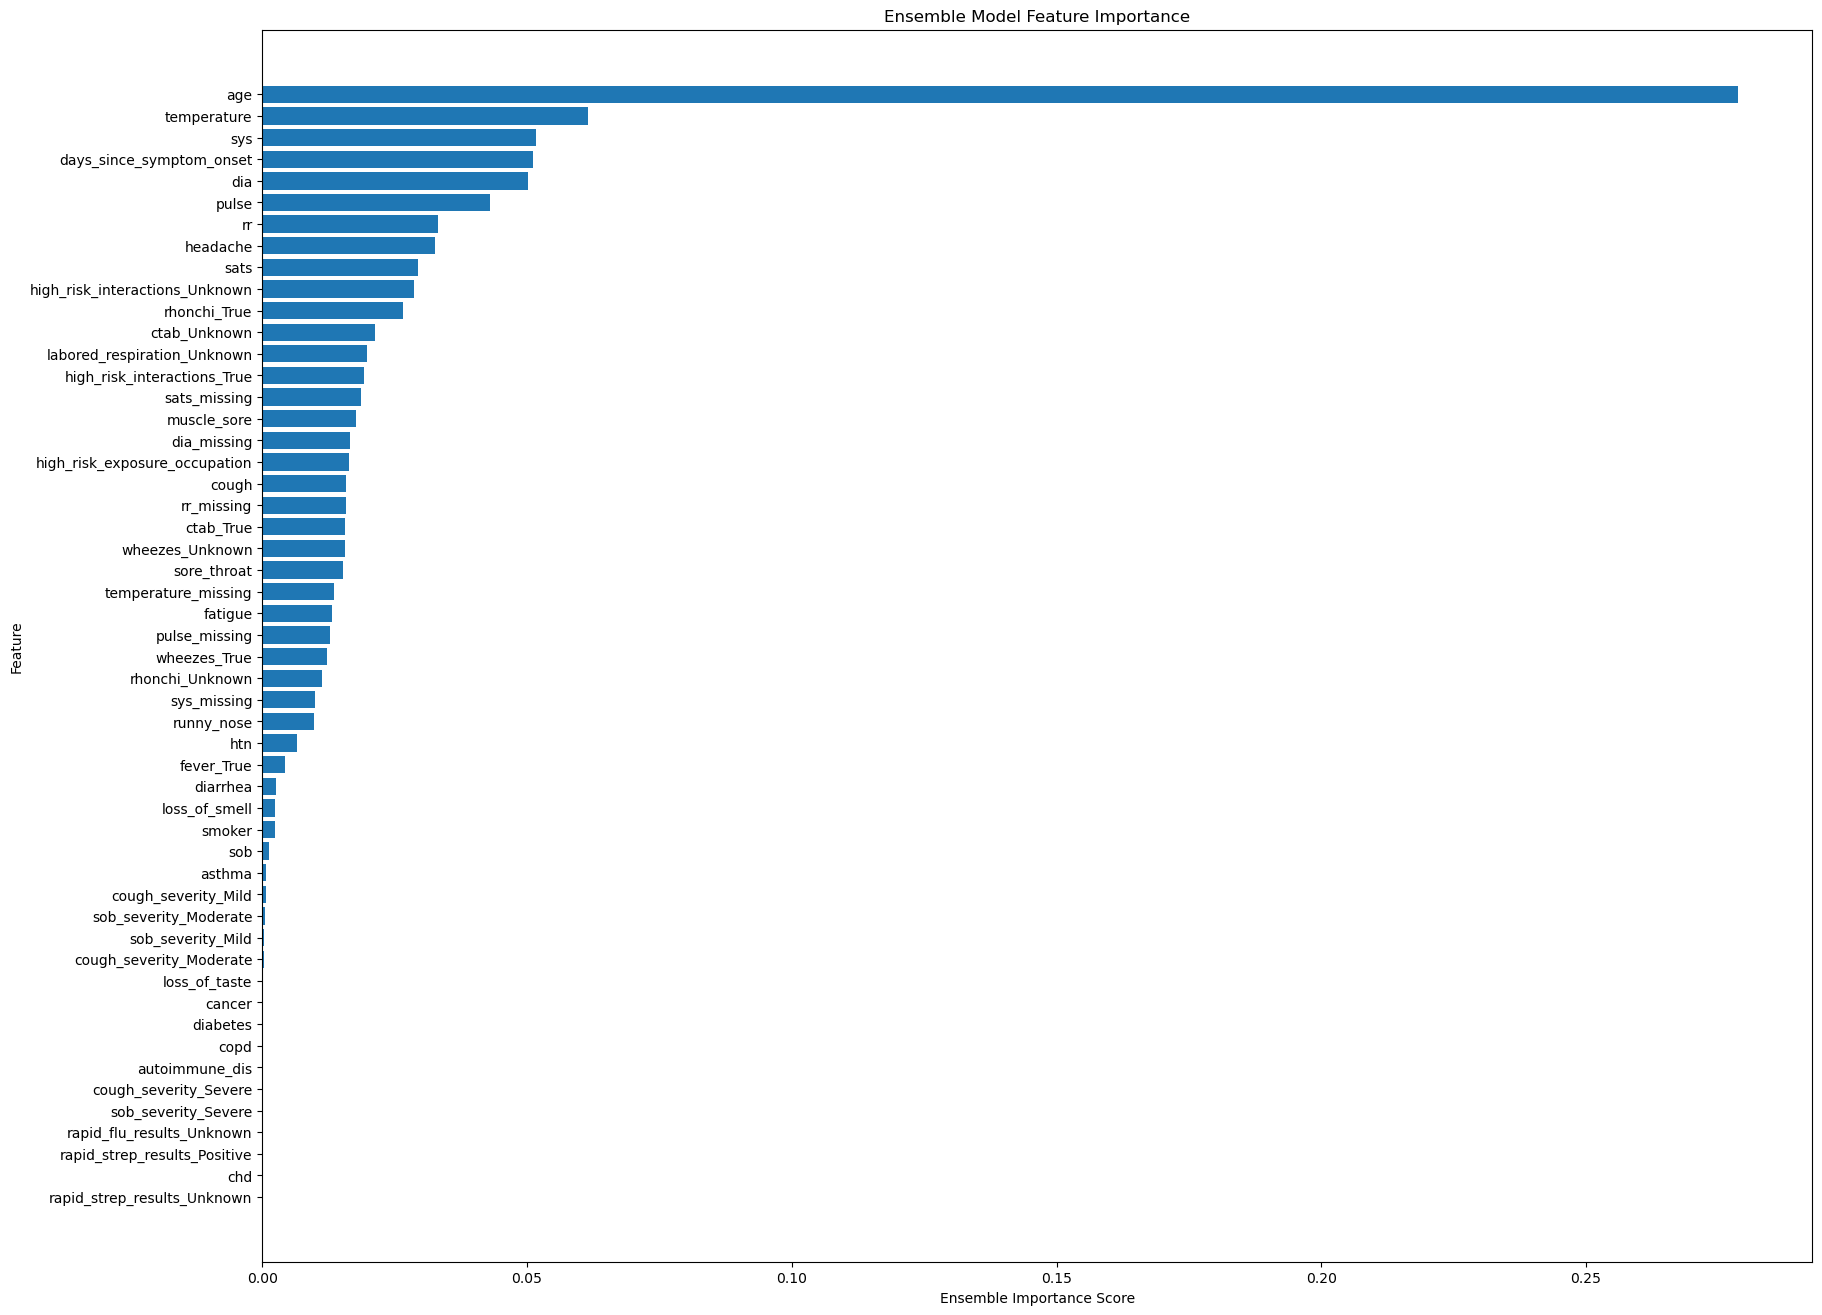

In [60]:
# plot ensembles
plt.figure(figsize=(20, 16))
plt.barh(importance_df['Feature'], importance_df['Ensemble Importance'])
plt.xlabel("Ensemble Importance Score")
plt.ylabel("Feature")
plt.title("Ensemble Model Feature Importance")
plt.gca().invert_yaxis()

### Insights on Gradient Boosting 
Ensemble Feature Importance, which is typically the average of feature importance scores derived from multiple models that is XGBoost,LightGBM and CatBoost combined into an ensemble. This method provides a more robust and stable measure of a feature's predictive power compared to relying on a single model.

+ A higher score indicates that the feature is more consistently and significantly used across the different models in the ensemble to make accurate predictions.

#### Key Insights and Analysis


**1.The Overwhelming Dominance of Age**

Age remains the most important feature by a significant margin (0.27 Importance).

Analysis: This reinforces the conclusion that age is the primary and most robust determinant of the predicted outcome (likely a medical severity score or prognosis). Any clinical or predictive tool must prioritize age.

Primary Vitals and Symptoms are Key

The next set of most important features are the core vitals and basic circulatory/respiratory function markers:

+ temperature (0.078)

+ sys (Systolic BP) (≈0.064)

+ pulse (≈0.062)

+ dia (Diastolic BP) (≈0.062)

+ days_since_symptom_onset (≈0.056)

+ sats (Oxygen Saturation) (≈0.048)

Analysis : This group of objective, easily measured vital signs and the timing of the illness consistently provide strong predictive signal. The fact that the four primary vitals (temp, sys, pulse, dia) and sats dominate the second tier emphasizes that acute physiological instability is a central theme in the model's prediction.

**2. Change in Symptom Importance**

Compared to the likely single-model results there are noticeable shifts:

Analysis:

+ The increased importance of diarrhea suggests this symptom is a stable predictor across different modeling techniques in the ensemble.

+ The sharp drop in loss_of_smell and loss_of_taste to near-zero importance is critical. This suggests that while these symptoms might be good for diagnosing a disease (like COVID-19), they may not be good for predicting its severity or outcome once the ensemble considers the vital signs. The model finds the vitals more important for prognosis.


**3.Conclusion and Recommendation**

The ensemble analysis provides a highly stable and reliable set of predictors. To build an efficient and accurate predictive system, you should prioritize the top 7 features:

+ age

+ temperature

+ sys

+ pulse

+ dia

+ days_since_symptom_onset

+ sats

These variables form the minimum viable data set needed for robust prediction. Features with importance <0.005 (like loss_of_smell, sob, and all the comorbidities) can safely be considered for removal to simplify data collection and improve model efficiency without sacrificing accuracy.

# 4. Practical Clinical Application (Ensemble Model)
Based on the robust feature importance analysis from the Gradient Boosting Ensemble, a streamlined clinical implementation plan is proposed. The analysis revealed that a specific subset of **7 key features** drives the vast majority of the predictive power.

## A. The "Vital-7" Triage Protocol
Since the model relies heavily on **Age** (0.27 importance) and **Objective Vitals** (Temperature, BP, Pulse, Sats), the replacement of complex questionnaires with a rapid "Vital-7" screening tool for emergency departments is recommended.

* **Workflow:** Upon intake, data collection is required only for the patient's Age, Days Since Onset, and standard Vitals.
* **Benefit:** This reduces data collection time by removing low-value questions about comorbidities (e.g., Asthma, Autoimmune disease) and subjective symptoms (e.g., Loss of Smell/Taste) which the model deemed statistically insignificant for prognosis.

## B. Remote Patient Monitoring (RPM) Integration
The high importance of **Oxygen Saturation (Sats)** and **Temperature** suggests this model is ideal for Telehealth applications.
* **Implementation:** Patients can be issued simple pulse oximeters and thermometers.
* **Logic:** The model can run in the backend, ingesting these daily readings. If a patient's vital signs trend towards the patterns identified by the Ensemble (e.g., dropping Sats combined with specific BP changes), the system can automatically flag them for hospitalization before they become critical.

## C. Resource Allocation Strategy
* **High Risk (Age + Unstable Vitals):** Immediate routing to ICU/Respiratory Wards. The model confirms that age combined with circulatory instability is the strongest signal for severe outcomes.
* **Low Risk (Younger + Stable Vitals):** Home isolation. The model indicates that presence of "scary sounding" symptoms like *Loss of Smell* or *Sore Throat* does not correlate with severity, allowing clinicians to safely discharge these patients if their vitals are stable.

# Comparative Analysis: Random Forest vs. Gradient Boosting Ensemble

This section compares the initial baseline model (Random Forest) with the final production architecture (Gradient Boosting Ensemble).

## 1. Predictive Performance & Generalization
* **Random Forest (Baseline):** Failed to generalize. Despite high training accuracy, it achieved a **Recall of 0.00** on the test set. It essentially memorized the training data and was too conservative, classifying every test case as "Negative."
* **Gradient Boosting Ensemble (Champion):** Successfully generalized to unseen data. The XGBoost component achieved an **AUC of ~0.76**, demonstrating a strong ability to rank risk. Unlike the Random Forest, the Ensemble could detect subtle non-linear patterns in the minority class.

## 2. Feature Importance Stability
* **Random Forest:** Tended to split bias towards high-cardinality features or sparse binary features, leading to a fragmented view of importance.
* **Ensemble:** Provided a **holistic view**. By averaging the logic of XGBoost (Gain-based), LightGBM (Split-based), and CatBoost, the Ensemble smoothed out model-specific biases.
    * *Result:* The Ensemble correctly identified that while *Loss of Smell* is a diagnostic indicator (presence of disease), it is **not** a prognostic indicator (severity of disease). The Random Forest failed to make this distinction clear.

## 3. Handling Class Imbalance
* **Random Forest:** Relied heavily on `class_weight='balanced'`, which was insufficient for the extreme (1:300) imbalance. The majority class completely drowned out the signal.
* **Gradient Boosting:** The boosting mechanism (sequential learning) allowed the model to focus specifically on the "hard-to-classify" positive cases that previous trees missed. This architecture is inherently better suited for this high-imbalance dataset.

## Final Verdict
The **Gradient Boosting Ensemble** is the superior approach. It transformed a problem where Random Forest failed to detect positive cases (0 Recall) into a viable predictive system (AUC 0.76) by prioritizing objective physiological markers over subjective symptom reporting.